# AI Adoption, Productivity, and Growth: A Cross-Country Macroeconomic Analysis
### DATA 319 Final project 
### Solo Team 
### Seohyeon Yoon

## 1. Setup

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy import stats
from numpy.linalg import inv, eigvals

np.random.seed(0)

## 2. Data Cleaning

In [19]:
ai_pubs_pc = pd.read_csv("ai_pubs_per_capita.csv")
ai_pubs_time = pd.read_csv("ai_pubs_time.csv")
ai_skills = pd.read_csv("ai_skills.csv")
ai_vc = pd.read_csv("ai_vc_investment.csv")

labor_prod = pd.read_csv("labor_productivity.csv")
gdp_growth = pd.read_csv("gdp_growth.csv")
unemployment = pd.read_csv("unemployment.csv")

# AI Publications Per Capita
ai_pubs_pc_clean = ai_pubs_pc[
    (ai_pubs_pc["ai_concept"] == "All AI research") &
    (ai_pubs_pc["impact_level"] == "All works") &
    (ai_pubs_pc["pub_type"] == "All publication types")
].copy()

ai_pubs_pc_clean = ai_pubs_pc_clean.rename(columns={
    "Country/territory": "country_code",
    "Country/territory_label": "country",
    "publications": "ai_pubs_per_capita",
    "year": "year"
})

ai_pubs_pc_clean = ai_pubs_pc_clean[
    ["country", "country_code", "year", "ai_pubs_per_capita"]
]

In [20]:
# ai skills

import pycountry 

def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

ai_skills_clean = ai_skills.rename(columns={
    "Country": "country_code", 
    "Country_label": "country",
    "AI_engineering_skills_penetration_factor": "ai_skills"
})


ai_skills_clean["country_code"] = ai_skills_clean["country_code"].apply(iso2_to_iso3)


print(ai_skills_clean.head())


   ai_skills country_code         country
0      2.627          USA   United States
1      2.511          IND           India
2      1.400          GBR  United Kingdom
3      1.318          DEU         Germany
4      1.315          BRA          Brazil


In [21]:
# AI VC Investment
ai_vc_clean = ai_vc[
    (ai_vc["INDUSTRY"] == "-- All industries --") &
    (ai_vc["STAGE"] == "VC")
].copy()

ai_vc_clean = ai_vc_clean.rename(columns={
    "Country": "country_code",
    "Country_label": "country",
    "Sum_of_deals": "ai_vc_investment",
    "Year": "year"
})

ai_vc_clean = ai_vc_clean.groupby(
    ["country", "country_code", "year"], as_index=False
)["ai_vc_investment"].sum()


In [22]:
# labor productivity (wide -> long)
labor_prod_clean = labor_prod.rename(columns={
    "REF_AREA_LABEL": "country"
})

year_cols = labor_prod_clean.columns[labor_prod_clean.columns.str.isnumeric()]

labor_prod_long = labor_prod_clean.melt(
    id_vars=["country"],
    value_vars=year_cols,
    var_name="year",
    value_name="labor_productivity"
)

labor_prod_long["year"] = labor_prod_long["year"].astype(int)


In [23]:
# GDP Growth (Filter to Growth Only → Wide → Long)
gdp_growth_clean = gdp_growth[
    gdp_growth["INDICATOR"].str.contains("Gross domestic product", case=False, na=False)
].copy()

gdp_growth_clean = gdp_growth_clean.rename(columns={"COUNTRY": "country"})

year_cols = gdp_growth_clean.columns[gdp_growth_clean.columns.str.isnumeric()]

gdp_growth_long = gdp_growth_clean.melt(
    id_vars=["country"],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_growth"
)

gdp_growth_long["year"] = gdp_growth_long["year"].astype(int)


In [24]:
# Unemployment (Wide → Long)
unemp_clean = unemployment.rename(columns={"COUNTRY": "country"})

year_cols = unemp_clean.columns[unemp_clean.columns.str.isnumeric()]

unemp_long = unemp_clean.melt(
    id_vars=["country"],
    value_vars=year_cols,
    var_name="year",
    value_name="unemployment"
)

unemp_long["year"] = unemp_long["year"].astype(int)


In [25]:
df = ai_pubs_pc_clean.merge(
    ai_vc_clean, on=["country", "country_code", "year"], how="left"
)

df = df.merge(
    labor_prod_long, on=["country", "year"], how="left"
)

df = df.merge(
    gdp_growth_long, on=["country", "year"], how="left"
)

df = df.merge(
    unemp_long, on=["country", "year"], how="left"
)

df = df.merge(
    ai_skills_clean[["country_code", "ai_skills"]],
    on="country_code",
    how="left"
)

In [26]:
# recent AI-era years
df_recent = df[(df["year"] >= 2018) & (df["year"] <= 2023)].copy()
core_vars = ["ai_pubs_per_capita",
             "ai_vc_investment",
             "labor_productivity",
             "gdp_growth",
             "unemployment"]

country_missing = (
    df_recent.groupby(["country", "country_code"])[core_vars]
    .apply(lambda x: x.isna().mean().mean())
    .reset_index(name="missing_rate")
)

keep_countries = country_missing[country_missing["missing_rate"] <= 0.5]

df_clean = df_recent.merge(
    keep_countries[["country", "country_code"]],
    on=["country", "country_code"],
    how="inner"
)

df_clean = df_clean.sort_values(["country", "year"]).reset_index(drop=True)

df = df_clean


In [27]:
df["ai_skills"].notna().sum()

270

In [28]:
df.info()
df.sample(10, random_state=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695 entries, 0 to 694
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             695 non-null    object 
 1   country_code        695 non-null    object 
 2   year                695 non-null    int64  
 3   ai_pubs_per_capita  695 non-null    float64
 4   ai_vc_investment    400 non-null    float64
 5   labor_productivity  686 non-null    float64
 6   gdp_growth          635 non-null    float64
 7   unemployment        473 non-null    float64
 8   ai_skills           270 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 49.0+ KB


,country,country_code,year,ai_pubs_per_capita,ai_vc_investment,labor_productivity,gdp_growth,unemployment,ai_skills
607,Sudan,SDN,2021,0.596204,NaN,16262.312982,772.366,NaN,NaN
243,Greece,GRC,2022,58.293783,NaN,91830.808360,20942.384,12.458333,0.599
603,Sri Lanka,LKA,2023,7.309064,NaN,35813.216724,3698.382,NaN,NaN
688,Zambia,ZMB,2022,0.146652,NaN,11129.422855,1456.901,6.098000,NaN
360,Lithuania,LTU,2023,25.432657,111.419129,92573.934745,NaN,NaN,0.350
31,Austria,AUT,2023,48.719570,101.717523,130342.728605,56215.892,5.108333,0.553
247,Guatemala,GTM,2021,0.022069,NaN,31280.712873,4911.934,2.174000,NaN
404,Mongolia,MNG,2019,4.203598,NaN,39979.878925,4309.049,9.090250,NaN
113,Burundi,BDI,2018,0.998336,NaN,2099.621384,256.051,NaN,NaN
541,Romania,ROU,2023,21.986211,174.924203,98265.395203,18412.783,5.566667,0.571


In [29]:
df.isna().sum()

country                 0
country_code            0
year                    0
ai_pubs_per_capita      0
ai_vc_investment      295
labor_productivity      9
gdp_growth             60
unemployment          222
ai_skills             425
dtype: int64

In [30]:
df.shape


(695, 9)

## 3. Numeric Matrix Construction

In [31]:
# Matrix for Correlation Analysis
corr_vars = [
    "ai_pubs_per_capita",
    "ai_vc_investment",
    "ai_skills",
    "labor_productivity",
    "gdp_growth",
    "unemployment"
]

corr_data = df[corr_vars].copy()

print("Correlation matrix complete-case rows:", corr_data.shape[0])


Correlation matrix complete-case rows: 695


In [32]:
# PCA Data (Country-level AI variables)
ai_vars = [
    "ai_pubs_per_capita",
    "ai_vc_investment",
    "ai_skills"
]

# Aggregate AI variables to country level (mean over available years)
ai_country = (
    df.groupby(["country", "country_code"], as_index=False)[
        ["ai_pubs_per_capita", "ai_vc_investment"]
    ].mean()
)

ai_country = ai_country.merge(
    ai_skills_clean,
    on=["country", "country_code"],
    how="inner"
)

ai_country = ai_country.dropna()

print("Countries usable for PCA:", ai_country.shape[0])


Countries usable for PCA: 44


In [33]:
# Matrix for Multivariate Normality Testing
mvn_vars = [
    "ai_pubs_per_capita",
    "labor_productivity",
    "gdp_growth"
]

mvn_data = df[mvn_vars].dropna().copy()

print("MVN test rows (3 vars complete):", mvn_data.shape[0])


MVN test rows (3 vars complete): 626


## 4. Correlation Matrix

In [34]:
corr_vars = [
    "ai_pubs_per_capita",
    "ai_vc_investment",
    "labor_productivity",
    "gdp_growth",
    "unemployment"
]

corr_data = df[corr_vars]


In [35]:
corr_matrix = corr_data.corr()
corr_matrix


,ai_pubs_per_capita,ai_vc_investment,labor_productivity,gdp_growth,unemployment
ai_pubs_per_capita,1.000000,0.116239,0.793686,0.839397,-0.172283
ai_vc_investment,0.116239,1.000000,0.151471,0.198566,-0.069296
labor_productivity,0.793686,0.151471,1.000000,0.918987,-0.130996
gdp_growth,0.839397,0.198566,0.918987,1.000000,-0.245221
unemployment,-0.172283,-0.069296,-0.130996,-0.245221,1.000000


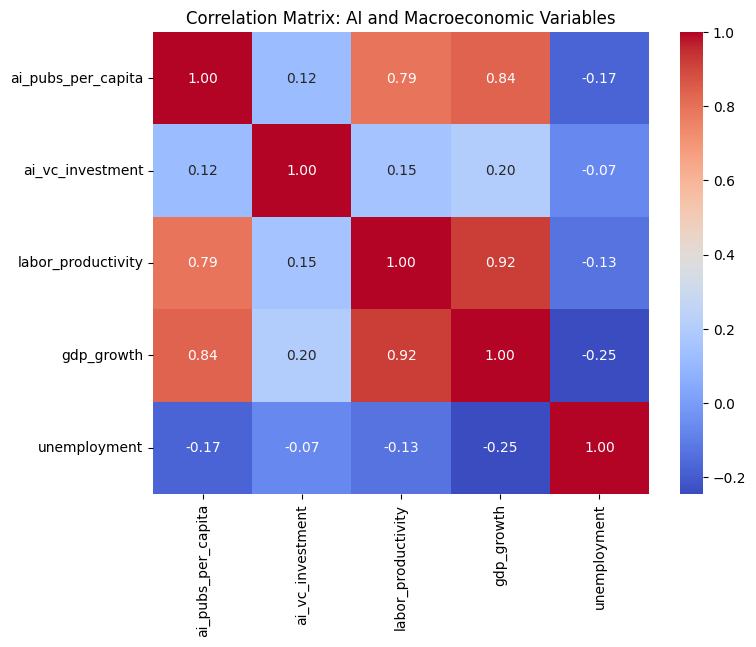

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: AI and Macroeconomic Variables")
plt.show()


## 5. PCA on AI variables

In [37]:
ai_vars = ["ai_pubs_per_capita", "ai_vc_investment", "ai_skills"]

#added code lines
X_ai_log = np.log1p(ai_country[ai_vars])

X_ai = X_ai_log.values

scaler = StandardScaler()
X_ai_std = scaler.fit_transform(X_ai)

pca = PCA()
X_pca = pca.fit_transform(X_ai_std)

In [38]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.61290188, 0.3523267 , 0.03477142])

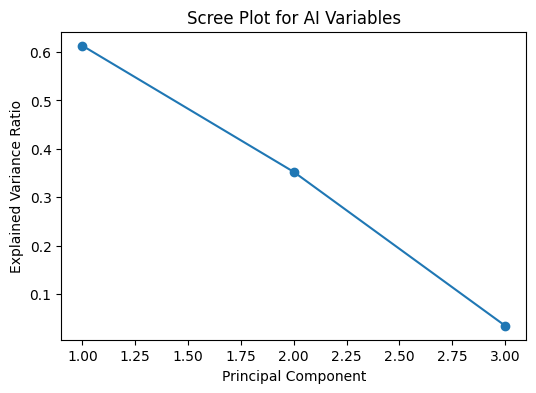

In [39]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1),
         explained_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot for AI Variables")
plt.show()


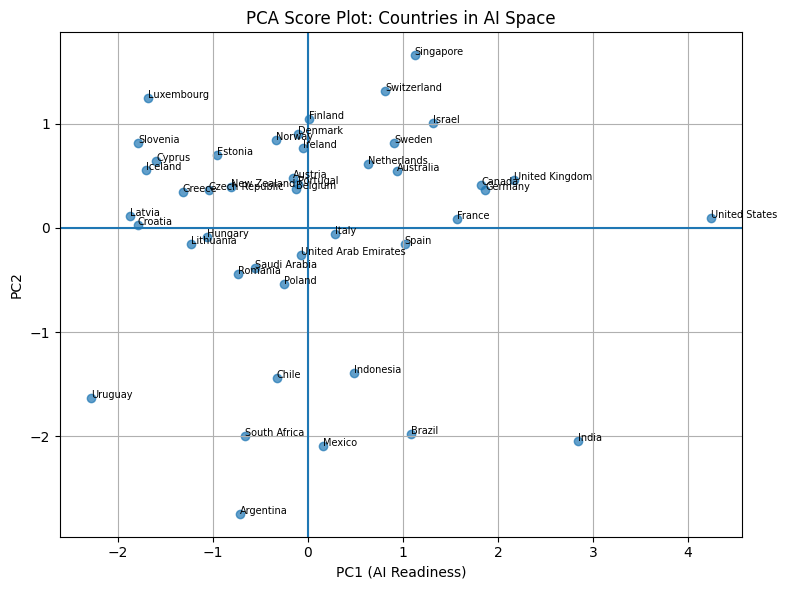

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)

for i, name in enumerate(ai_country["country"]):
    plt.text(X_pca[i, 0], X_pca[i, 1], name, fontsize=7)

plt.xlabel("PC1 (AI Readiness)")
plt.ylabel("PC2")
plt.title("PCA Score Plot: Countries in AI Space")

plt.axhline(0)
plt.axvline(0)

plt.grid(True)
plt.tight_layout()
plt.show()


In [59]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(ai_vars))],
    index=ai_vars
)

loadings


,PC1,PC2,PC3
ai_pubs_per_capita,0.088866,0.962191,-0.257471
ai_vc_investment,0.713198,0.118978,0.690792
ai_skills,0.695307,-0.245016,-0.675659


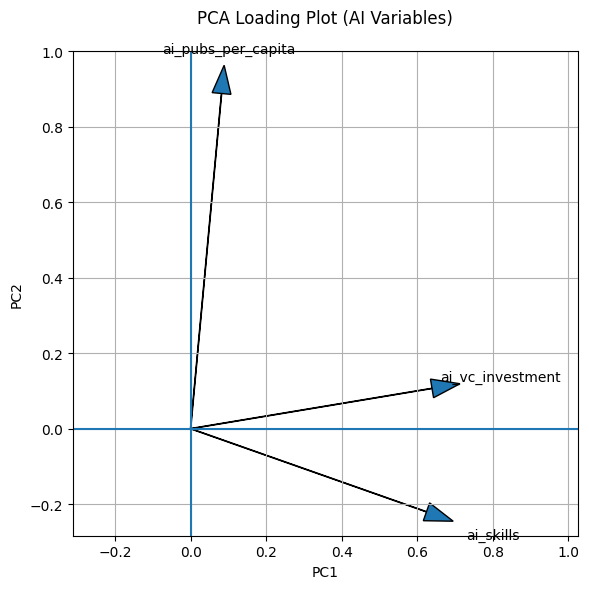

In [60]:
plt.figure(figsize=(6, 6))

for i, var in enumerate(ai_vars):
    x = loadings.iloc[i, 0]
    y = loadings.iloc[i, 1]

    plt.arrow(0, 0,
              x, y,
              head_width=0.05,
              length_includes_head=True)

    x_text = x * 1.15
    y_text = y * 1.15

    if var == "ai_pubs_per_capita":
        y_text -= 0.1

    plt.text(x_text, y_text, var, fontsize=10,
             ha="center", va="center")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Loading Plot (AI Variables)", pad=20)

plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()


In [43]:
ai_country["ai_index"] = X_pca[:, 0]
ai_country.head()


,country,country_code,ai_pubs_per_capita,ai_vc_investment,ai_skills,ai_index
0,Argentina,ARG,1.913665,40.382180,0.760,-0.710850
1,Australia,AUS,56.785199,812.488392,0.954,0.942123
2,Austria,AUT,46.185292,234.072655,0.553,-0.157745
3,Belgium,BEL,44.216837,178.605812,0.627,-0.129620
4,Brazil,BRA,5.540260,600.271508,1.315,1.085853


## 6. K-Means/Hierarchical Clustering

In [44]:
df = df.merge(
    ai_country[["country", "country_code", "ai_index"]],
    on=["country", "country_code"],
    how="left"
)

df["ai_index"].notna().sum()
df[["country", "year", "ai_index"]].sample(5, random_state=0)

,country,year,ai_index
607,Sudan,2021,NaN
243,Greece,2022,-1.315163
603,Sri Lanka,2023,NaN
688,Zambia,2022,NaN
360,Lithuania,2023,-1.225485


In [45]:
cluster_vars = ["ai_index", "labor_productivity", "gdp_growth"]

cluster_data = df[cluster_vars].dropna().copy()

print("Rows available for clustering:", cluster_data.shape[0])

Rows available for clustering: 216


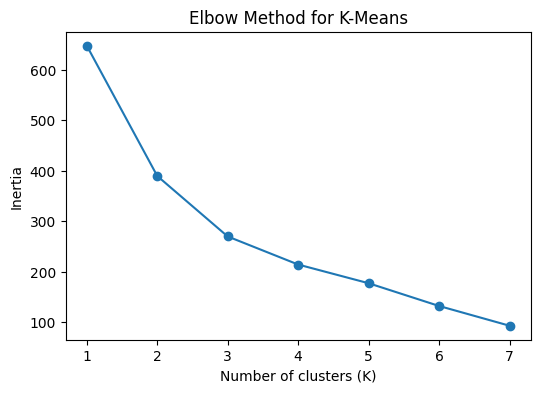

In [46]:
scaler = StandardScaler()
X_cluster_std = scaler.fit_transform(cluster_data)

inertia = []

K_range = range(1, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_cluster_std)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()


In [47]:
kmeans = KMeans(n_clusters=3, random_state=0)
cluster_labels = kmeans.fit_predict(X_cluster_std)

cluster_data["cluster"] = cluster_labels

df_clustered = df.loc[cluster_data.index].copy()
df_clustered["cluster"] = cluster_labels

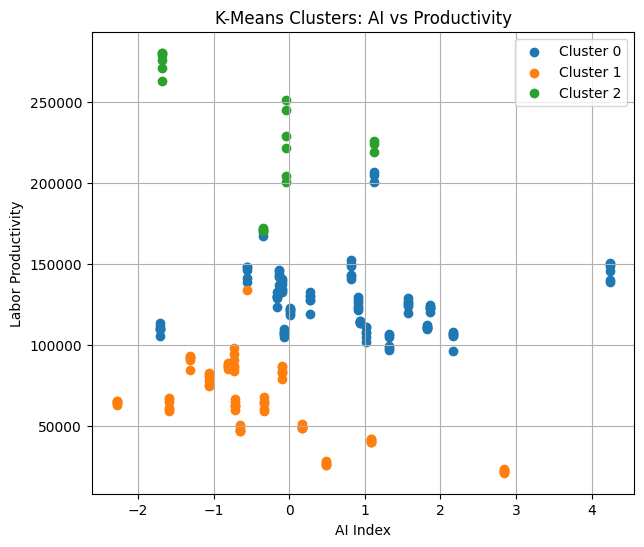

In [48]:
plt.figure(figsize=(7, 6))

for c in sorted(df_clustered["cluster"].unique()):
    subset = df_clustered[df_clustered["cluster"] == c]
    plt.scatter(subset["ai_index"],
                subset["labor_productivity"],
                label=f"Cluster {c}")

plt.xlabel("AI Index")
plt.ylabel("Labor Productivity")
plt.title("K-Means Clusters: AI vs Productivity")
plt.legend()
plt.grid(True)
plt.show()


In [49]:
# HIERARCHICAL CLUSTERING
cluster_country = (
    df.groupby(["country", "country_code"], as_index=False)[
        ["ai_index", "labor_productivity", "gdp_growth"]
    ].mean()
)

cluster_country = cluster_country.dropna()

X_hier_std = StandardScaler().fit_transform(
    cluster_country[["ai_index", "labor_productivity", "gdp_growth"]]
)

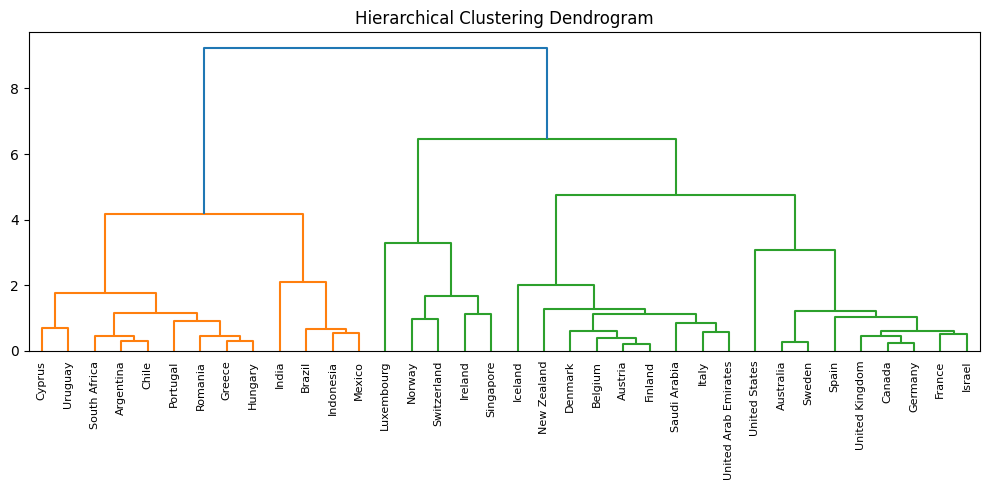

In [50]:
# Dendrogram (Hierarchical Clustering Plot)
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_hier_std, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z,
           labels=cluster_country["country"].values,
           leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
plt.show()


## 7. Multivariate Normality Testing

In [51]:
# Build the MVN Dataset (Strict Complete-Case)
mvn_vars = [
    "ai_pubs_per_capita",
    "labor_productivity",
    "gdp_growth"
]

mvn_data = df[mvn_vars].dropna().copy()
print("Rows used for MVN testing:", mvn_data.shape[0])


Rows used for MVN testing: 626


In [52]:
mu = mvn_data.mean().values
Sigma = mvn_data.cov().values

mu, Sigma

(array([1.95313426e+01, 6.40005012e+04, 2.04120677e+04]),
 array([[7.64122759e+02, 1.18553846e+06, 5.93268961e+05],
        [1.18553846e+06, 2.87953180e+09, 1.25880576e+09],
        [5.93268961e+05, 1.25880576e+09, 6.51593497e+08]]))

In [53]:
X = mvn_data.values
Sigma_inv = inv(Sigma)

md = np.array([
    (x - mu).T @ Sigma_inv @ (x - mu)
    for x in X
])

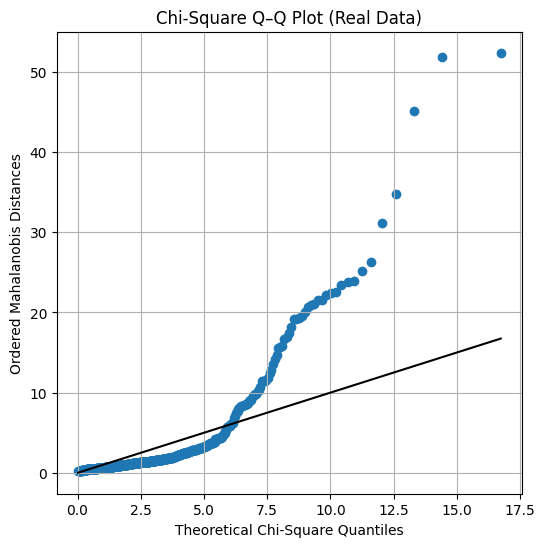

In [54]:
#Chi-Square Q–Q Plot (Real Data vs Theoretical MVN)

df_chi2 = len(mvn_vars)

md_sorted = np.sort(md)
chi2_quantiles = stats.chi2.ppf(
    (np.arange(1, len(md)+1) - 0.5) / len(md),
    df=df_chi2
)

plt.figure(figsize=(6, 6))
plt.scatter(chi2_quantiles, md_sorted)
plt.plot(chi2_quantiles, chi2_quantiles, color="black")

plt.xlabel("Theoretical Chi-Square Quantiles")
plt.ylabel("Ordered Mahalanobis Distances")
plt.title("Chi-Square Q–Q Plot (Real Data)")
plt.grid(True)
plt.show()

In [55]:
# Simulate MVN Data Using Same Mean & Covariance

X_sim = np.random.multivariate_normal(mu, Sigma, size=len(mvn_data))

md_sim = np.array([
    (x - mu).T @ Sigma_inv @ (x - mu)
    for x in X_sim
])

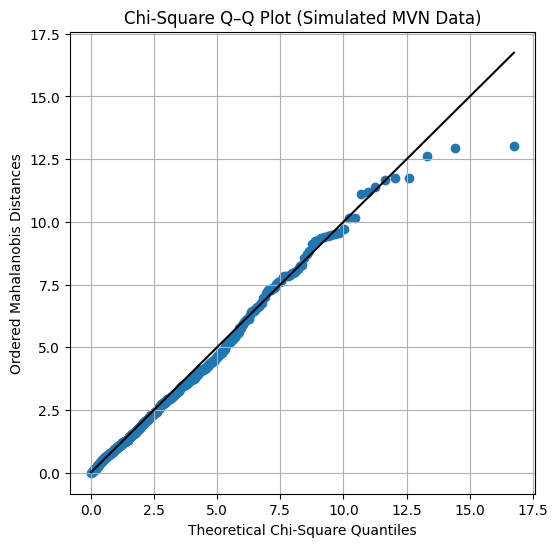

In [56]:
# Chi-Square Q–Q Plot for SIMULATED Data
md_sim_sorted = np.sort(md_sim)

plt.figure(figsize=(6, 6))
plt.scatter(chi2_quantiles, md_sim_sorted)
plt.plot(chi2_quantiles, chi2_quantiles, color="black")

plt.xlabel("Theoretical Chi-Square Quantiles")
plt.ylabel("Ordered Mahalanobis Distances")
plt.title("Chi-Square Q–Q Plot (Simulated MVN Data)")
plt.grid(True)
plt.show()


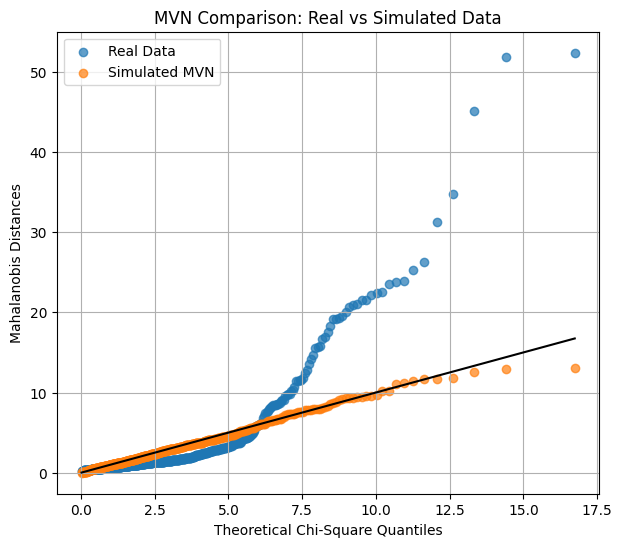

In [57]:
# Comparison Plot
plt.figure(figsize=(7, 6))
plt.scatter(chi2_quantiles, md_sorted, label="Real Data", alpha=0.7)
plt.scatter(chi2_quantiles, md_sim_sorted, label="Simulated MVN", alpha=0.7)

plt.plot(chi2_quantiles, chi2_quantiles, color="black")

plt.xlabel("Theoretical Chi-Square Quantiles")
plt.ylabel("Mahalanobis Distances")
plt.title("MVN Comparison: Real vs Simulated Data")
plt.legend()
plt.grid(True)
plt.show()


In [58]:
df.shape


(695, 10)